# Graph Theory Fundamentals

Primary source: *Mathematical Foundations of Geometric Deep Learning*, §7.1–§7.2, pp. 65–73 of the supplied manuscript. Supplement: William L. Hamilton, [*Graph Representation Learning*](https://www.cs.mcgill.ca/~wlh/grl_book/), especially Chapter 2, *Background and Traditional Approaches*.

This notebook preserves the manuscript's examples and adds NetworkX visualizations and code. It prepares the graph-theoretic vocabulary for the next notebook on Graph Neural Networks (GNNs).

**Scope:** §7.3, *Vector Fields on Graphs*, is intentionally excluded.

## 1. Graphs, vertices, edges, neighborhoods

A graph is an ordered pair

$$G=(V,E),$$

where \(V\) is the set of vertices and \(E\) describes the connections. In a directed graph, an edge \((u,v)\) is ordered and need not imply \((v,u)\). In an undirected graph, an edge \(\{u,v\}\) is symmetric. An edge \((v,v)\) is a self-loop.

The one-hop neighborhood is

$$\mathcal N(v_i)=\{v_j:(v_i,v_j)\in E\}.$$

A subgraph \(H=(V_H,E_H)\) of \(G=(V_G,E_G)\) satisfies \(V_H\subseteq V_G\) and \(E_H\subseteq E_G\). The neighborhood subgraph includes a vertex, its neighbors, and the edges among those vertices.

**Examples:** citation networks are naturally directed; mutual friendships are often modeled as undirected. An edgeless set of vertices is also a graph, with \(E=\varnothing\).

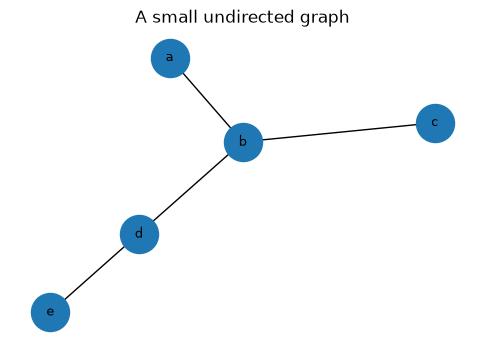

Neighborhood of b: ['a', 'c', 'd']


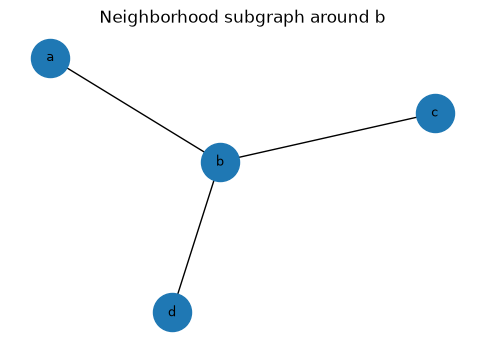

In [1]:
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(G, title, pos=None, labels=None, node_size=750):
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    plt.figure(figsize=(6, 4))
    nx.draw_networkx(G, pos=pos, labels=labels, with_labels=True,
                     node_size=node_size, font_size=9, arrows=G.is_directed())
    weights = nx.get_edge_attributes(G, "weight")
    if weights:
        nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=weights)
    plt.title(title)
    plt.axis("off")
    plt.show()

G = nx.Graph()
G.add_edges_from([("a","b"), ("b","c"), ("b","d"), ("d","e")])
draw_graph(G, "A small undirected graph")
print("Neighborhood of b:", sorted(G.neighbors("b")))
draw_graph(G.subgraph(["b", *G.neighbors("b")]).copy(), "Neighborhood subgraph around b")

## 2. Adjacency and degree matrices

After ordering the vertices \(v_1,\ldots,v_N\), the adjacency matrix \(A\in\mathbb R^{N\times N}\) records edges. For an unweighted graph,

$$
A_{ij}= 
\begin{cases}
1,&(v_i,v_j)\in E,\\
0,& \text{otherwise.}
\end{cases}
$$

For weighted graphs, \(A_{ij}\) stores the edge weight. A simple undirected graph has symmetric adjacency matrix \(A=A^\top\); a directed graph generally does not.

The diagonal degree matrix is

$$D_{ii}=\sum_j A_{ij}.$$

For weighted graphs this is the weighted degree (strength). Under the source-row convention, row sums and column sums of a directed adjacency matrix give out-degree and in-degree respectively.

In [2]:
order = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=order, dtype=int)
D = np.diag(A.sum(axis=1))
print("Vertex order:", order)
print("A =\n", A)
print("D =\n", D)
print("Symmetric adjacency?", np.array_equal(A, A.T))

Vertex order: ['a', 'b', 'c', 'd', 'e']
A =
 [[0 1 0 0 0]
 [1 0 1 1 0]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 0 0 1 0]]
D =
 [[1 0 0 0 0]
 [0 3 0 0 0]
 [0 0 1 0 0]
 [0 0 0 2 0]
 [0 0 0 0 1]]
Symmetric adjacency? True


### The manuscript's weighted four-node example

The manuscript uses $\{v_1, v_2, v_3, v_4\}$ with edge weights

$$w(v_1,v_2)=2, \quad w(v_1,v_3)=4, \quad w(v_2,v_3)=1, \quad w(v_3,v_4)=3.$$

The manuscript writes the corresponding adjacency matrix in the displayed edge direction. For shortest-path distances, we will treat these weights as undirected lengths, as in its worked calculation.

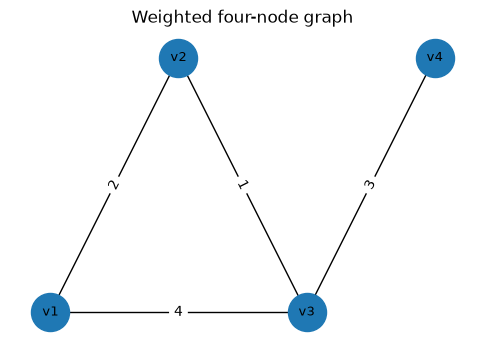

Adjacency matrix in order v1,v2,v3,v4:
[[0. 2. 4. 0.]
 [2. 0. 1. 0.]
 [4. 1. 0. 3.]
 [0. 0. 3. 0.]]
Shortest path v1 to v4: ['v1', 'v2', 'v3', 'v4']
Distance: 6
Diameter: 6


In [3]:
WG = nx.Graph()
WG.add_weighted_edges_from([
    ("v1","v2",2), ("v1","v3",4), ("v2","v3",1), ("v3","v4",3)
])
pos = {"v1":(0,0), "v2":(1,1), "v3":(2,0), "v4":(3,1)}
draw_graph(WG, "Weighted four-node graph", pos=pos)
print("Adjacency matrix in order v1,v2,v3,v4:")
print(nx.to_numpy_array(WG, nodelist=["v1","v2","v3","v4"], weight="weight"))
print("Shortest path v1 to v4:", nx.shortest_path(WG, "v1", "v4", weight="weight"))
print("Distance:", nx.shortest_path_length(WG, "v1", "v4", weight="weight"))
print("Diameter:", nx.diameter(WG, weight="weight"))

## 3. Connectivity, shortest paths, and diameter

A graph is connected if every pair of vertices is joined by a path. Otherwise it is disconnected.

For a weighted graph, the shortest-path (graph-geodesic) distance is

$$d_G(u,v)=\min_{P:u\leadsto v}\sum_{e\in P}w(e).$$

For unweighted graphs, each edge has length one. If no path exists, the manuscript uses $d_G(u,v)=\infty$. On a connected graph with positive edge lengths, shortest-path distance is a metric.

In the weighted example, $v_1\to v_2\to v_3\to v_4$ has length $2+1+3=6$, while $v_1\to v_3\to v_4$ has length $4+3=7$. Thus $d_G(v_1,v_4)=6$.

The diameter of a connected graph is the largest pairwise shortest-path distance:

$$\operatorname{diam}(G)=\max_{u,v\in V}d_G(u,v).$$

For disconnected graphs this maximum is infinite under the convention above; software users may instead report component-wise diameters.

In [4]:
print("All-pairs weighted shortest-path lengths:")
for source, distances in nx.all_pairs_dijkstra_path_length(WG, weight="weight"):
    print(source, distances)

print("\nDegrees:")
for v, degree in WG.degree():
    print(v, degree)

All-pairs weighted shortest-path lengths:
v1 {'v1': 0, 'v2': 2, 'v3': 3, 'v4': 6}
v2 {'v2': 0, 'v3': 1, 'v1': 2, 'v4': 4}
v3 {'v3': 0, 'v2': 1, 'v4': 3, 'v1': 3}
v4 {'v4': 0, 'v3': 3, 'v2': 4, 'v1': 6}

Degrees:
v1 2
v2 2
v3 3
v4 1


## 4. Graph families

### Point clouds and complete graphs

An edgeless graph $E=\varnothing$ is a point cloud in the manuscript's graph-theoretic terminology. A complete graph $K_N$ connects every pair of distinct vertices; every vertex has degree $N-1$.

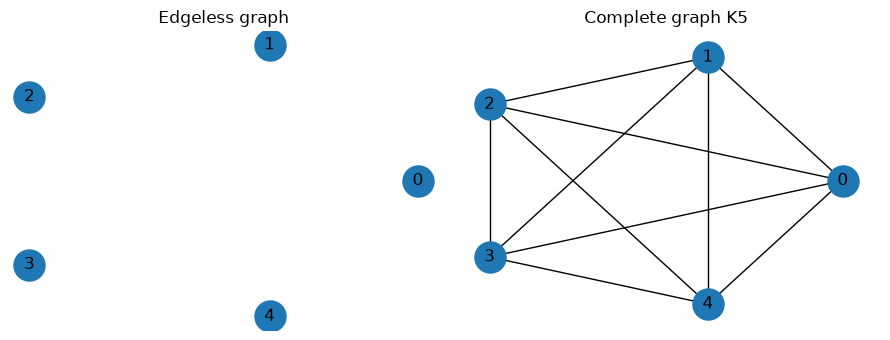

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
P = nx.empty_graph(5)
posP = {i:(math.cos(2*math.pi*i/5), math.sin(2*math.pi*i/5)) for i in P}
nx.draw_networkx(P, pos=posP, ax=axes[0], node_size=500)
axes[0].set_title("Edgeless graph")
axes[0].axis("off")
K5 = nx.complete_graph(5)
nx.draw_networkx(K5, pos=nx.circular_layout(K5), ax=axes[1], node_size=500)
axes[1].set_title("Complete graph K5")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Bipartite graphs

A bipartite graph partitions $V=V_1\cup V_2$, with $V_1\cap V_2=\varnothing$, and every edge joins the two different parts. No edge joins two vertices in the same part. User–item recommendation graphs are a standard example.

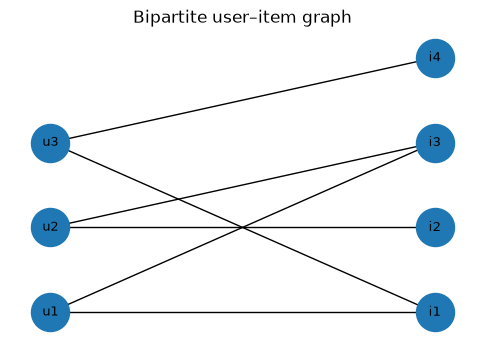

In [6]:
B = nx.Graph()
users = ["u1","u2","u3"]
items = ["i1","i2","i3","i4"]
B.add_nodes_from(users, bipartite=0)
B.add_nodes_from(items, bipartite=1)
B.add_edges_from([("u1","i1"),("u1","i3"),("u2","i2"),
                  ("u2","i3"),("u3","i1"),("u3","i4")])
pos = {**{u:(0,i) for i,u in enumerate(users)},
       **{it:(1,i) for i,it in enumerate(items)}}
draw_graph(B, "Bipartite user–item graph", pos=pos)

### Paths, cycles, trees, and DAGs

- A path graph $P_N$ is a chain with $N$ vertices and $N-1$ edges.
- A cycle graph $C_N$ is one closed loop; every vertex has degree two.
- A tree is connected and acyclic. There is exactly one simple path between each pair, and a tree with $N$ vertices has $N-1$ edges.
- A directed acyclic graph (DAG) has no directed cycle. DAGs represent dependencies and computations.

An undirected tree can be oriented to form a DAG, but not every DAG is an oriented tree.

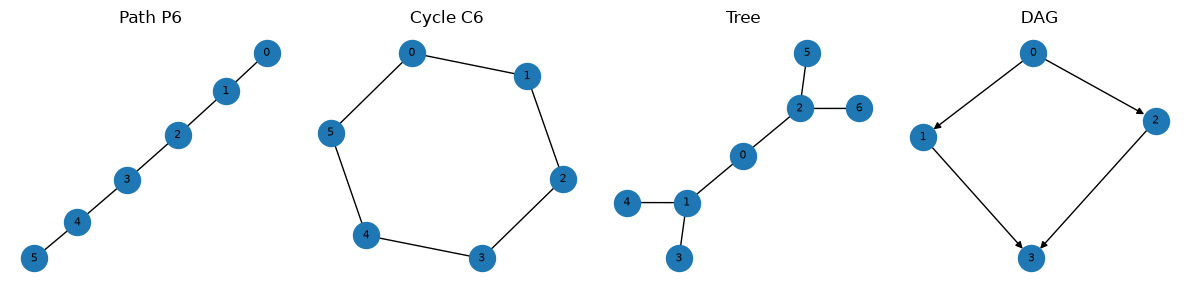

In [7]:
examples = [
    (nx.path_graph(6), "Path P6"),
    (nx.cycle_graph(6), "Cycle C6"),
    (nx.balanced_tree(2, 2), "Tree"),
    (nx.DiGraph([(0,1),(0,2),(1,3),(2,3)]), "DAG"),
]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (H, title) in zip(axes, examples):
    nx.draw_networkx(H, pos=nx.spring_layout(H, seed=3), ax=ax, node_size=350,
                     font_size=8, arrows=H.is_directed())
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Regular graphs

A graph is $k$-regular if every vertex has degree \(k\). The manuscript's examples include: edgeless graphs (0-regular), cycles (2-regular), complete graphs $K_N$ $(N-1)$-regular), and cubic graphs (3-regular). Regularity specifies degrees, not the entire graph structure.

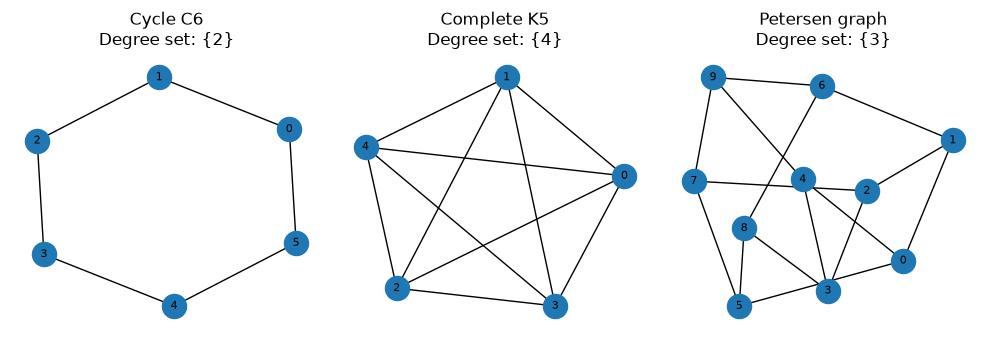

In [8]:
regulars = [("Cycle C6", nx.cycle_graph(6)),
            ("Complete K5", nx.complete_graph(5)),
            ("Petersen graph", nx.petersen_graph())]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, (name, H) in zip(axes, regulars):
    nx.draw_networkx(H, pos=nx.spring_layout(H, seed=4), ax=ax, node_size=300, font_size=8)
    ax.set_title(f"{name}\nDegree set: {set(dict(H.degree()).values())}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Geometric graphs

A geometric graph associates each vertex $v_i$ with a point $x_i$, typically in $\mathbb R^2$ or $\mathbb R^3$. Edges are defined using geometric proximity or another geometric rule.

Two common constructions:

- **Radius graph:** connect \(i,j\) when $d(x_i,x_j)\leq\varepsilon$.
- **\(k\)-nearest-neighbor graph:** connect each point to its \(k\) closest points.

A useful technical nuance: the directed \(k\)-NN relation has \(k\) outgoing neighbors per vertex, but an undirected symmetrization need not be \(k\)-regular.

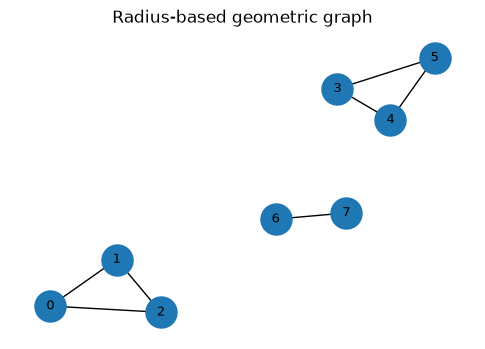

In [9]:
points = np.array([[.05,.10],[.20,.25],[.30,.08],[.70,.80],
                   [.82,.70],[.92,.90],[.56,.38],[.72,.40]])
pos = {i: points[i] for i in range(len(points))}
RG = nx.random_geometric_graph(len(points), radius=.28, pos=pos)
draw_graph(RG, "Radius-based geometric graph", pos=pos, node_size=500)

In molecular modelling, vertices may represent atoms and edges may represent bonds or proximity. The graph structure \((V,E)\) and positions \(x_i\in\mathbb R^3\) are distinct data. A model may need to respect arbitrary atom relabeling and, for geometric tasks, rotations and translations too.

## 6. Homophily and heterophily

Assign each vertex a class label $y_i$. The edge homophily ratio in the manuscript is

$$h=\frac{1}{|E|}\sum_{(v_i,v_j)\in E}\mathbf 1(y_i=y_j),$$

where $\mathbf{1}$ is one when the labels agree and zero otherwise. For undirected graphs, count each undirected edge once.

- \(h=1\): all edges join vertices with the same label.
- \(h=0\): all edges join different labels.
- intermediate values: a mixture.

Homophily is a property of a particular labeled graph, not a universal assumption. Heterophilic graphs are common in some tasks.

Edge homophily = 0.6666666666666666


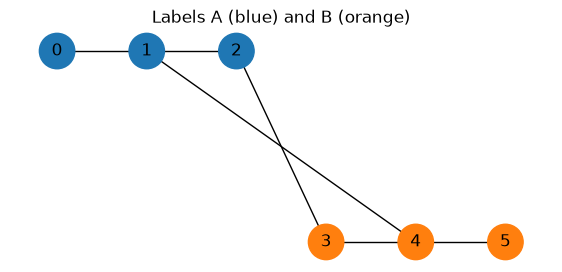

In [10]:
labels = {0:"A", 1:"A", 2:"A", 3:"B", 4:"B", 5:"B"}
HG = nx.Graph()
HG.add_edges_from([(0,1),(1,2),(3,4),(4,5),(2,3),(1,4)])
h = sum(labels[u] == labels[v] for u,v in HG.edges()) / HG.number_of_edges()
print("Edge homophily =", h)
pos = {0:(0,1),1:(1,1),2:(2,1),3:(3,0),4:(4,0),5:(5,0)}
colors = ["tab:blue" if labels[v]=="A" else "tab:orange" for v in HG]
plt.figure(figsize=(7,3))
nx.draw_networkx(HG, pos=pos, node_color=colors, node_size=650)
plt.title("Labels A (blue) and B (orange)")
plt.axis("off")
plt.show()

## 7. Meshes and simplicial complexes

A **mesh** is a discrete representation of a geometric domain, usually made from vertices, edges, and faces that approximate a surface. A **simplicial complex** is built from simplices (vertices, edges, triangles, tetrahedra, …) subject to face-inclusion rules.

A graph records vertices and pairwise edges. A simplicial complex can also record higher-dimensional relations, such as a filled triangle. Meshes appear in graphics, geometry processing, and physical simulation; simplicial complexes provide a route toward topological deep learning.

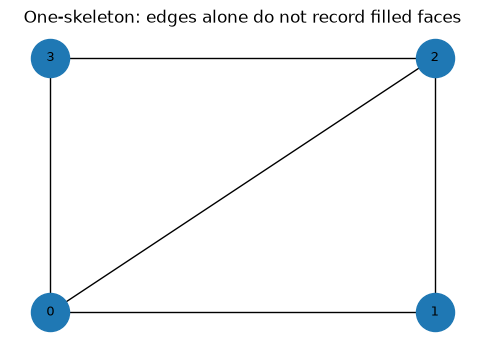

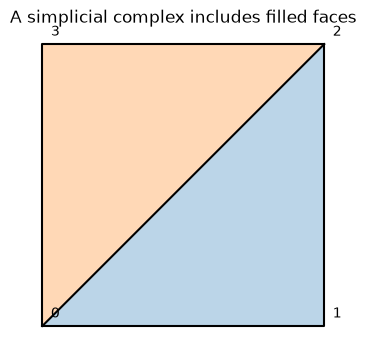

In [11]:
# One-skeleton of a square split into two triangles.
mesh = nx.Graph([(0,1),(1,2),(2,3),(3,0),(0,2)])
pos = {0:(0,0), 1:(1,0), 2:(1,1), 3:(0,1)}
draw_graph(mesh, "One-skeleton: edges alone do not record filled faces", pos=pos)
plt.figure(figsize=(4,4))
plt.fill([0,1,1],[0,0,1],alpha=.3,label="Triangle (0,1,2)")
plt.fill([0,1,0],[0,1,1],alpha=.3,label="Triangle (0,2,3)")
plt.plot([0,1,1,0,0],[0,0,1,1,0],"k-")
plt.plot([0,1],[0,1],"k-")
for i,(x,y) in enumerate([(0,0),(1,0),(1,1),(0,1)]):
    plt.text(x+.03,y+.03,str(i))
plt.title("A simplicial complex includes filled faces")
plt.axis("equal"); plt.axis("off"); plt.show()

## 8. Permutations and graph relabeling

The labels or indices assigned to vertices are arbitrary. A permutation matrix \(P\) encodes a relabeling. Under the convention used in the manuscript,

$$A'=PAP^\top.$$

Permutation matrices satisfy $P^{-1}=P^\top$ and $PP^\top=I$. Relabeling changes the matrix representation but preserves structural properties such as the degree multiset, connectivity, and adjacency eigenvalues.

In [12]:
G0 = nx.Graph([(0,1),(1,2),(2,3),(3,0),(0,2)])
A0 = nx.to_numpy_array(G0, nodelist=[0,1,2,3])
perm = [2,0,3,1]
P = np.eye(4)[perm]
Aprime = P @ A0 @ P.T
print("A =\n", A0)
print("P =\n", P)
print("P A P^T =\n", Aprime)
print("Eigenvalues before:", np.sort(np.linalg.eigvalsh(A0)))
print("Eigenvalues after: ", np.sort(np.linalg.eigvalsh(Aprime)))

A =
 [[0. 1. 1. 1.]
 [1. 0. 1. 0.]
 [1. 1. 0. 1.]
 [1. 0. 1. 0.]]
P =
 [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]
P A P^T =
 [[0. 1. 1. 1.]
 [1. 0. 1. 1.]
 [1. 1. 0. 0.]
 [1. 1. 0. 0.]]
Eigenvalues before: [-1.56155281e+00 -1.00000000e+00  4.44089210e-16  2.56155281e+00]
Eigenvalues after:  [-1.56155281e+00 -1.00000000e+00 -3.61718547e-30  2.56155281e+00]


### Permutation-invariant aggregation

A function of node features is permutation invariant if reordering the nodes does not change the output. Examples include

$$\sum_{i=1}^N x_i, \qquad  \frac1N \sum_{i=1}^N x_i, \qquad \max_i x_i.$$

Such operations can turn a collection of node features into a graph-level summary. This is a preview of a central idea for GNNs, not a treatment of message passing.

In [13]:
features = np.array([[1.,2.],[3.,-1.],[.5,4.]])
reordered = features[[2,0,1]]
print("Sum invariant:", np.allclose(features.sum(0), reordered.sum(0)))
print("Mean invariant:", np.allclose(features.mean(0), reordered.mean(0)))
print("Max invariant:", np.allclose(features.max(0), reordered.max(0)))

Sum invariant: True
Mean invariant: True
Max invariant: True


## 9. Graph homomorphisms and isomorphisms

For $G=(V_G,E_G)$ and $H=(V_H,E_H)$, a graph homomorphism $F:V_G\to V_H$ preserves edges:

$$(u,v)\in E_G\implies (F(u),F(v))\in E_H.$$

It need not be injective or surjective; multiple vertices may collapse to one, provided edges still map to edges.

A graph isomorphism is a bijection satisfying the stronger condition

$$(u,v)\in E_G\iff(F(u),F(v))\in E_H.$$

Thus isomorphic graphs have the same structure up to relabeling.

In [14]:
def is_graph_homomorphism(G, H, mapping):
    return all(H.has_edge(mapping[u], mapping[v]) for u,v in G.edges())

# Manuscript example: C6 -> K3, mapped repeatedly around the triangle.
C6, K3 = nx.cycle_graph(6), nx.complete_graph(3)
F = {i: i % 3 for i in range(6)}
print("C6 -> K3 homomorphism:", is_graph_homomorphism(C6, K3, F))

# Manuscript example: P11 -> C10; endpoints map to the same cycle vertex.
P11, C10 = nx.path_graph(11), nx.cycle_graph(10)
F2 = {i: i % 10 for i in range(11)}
print("P11 -> C10 homomorphism:", is_graph_homomorphism(P11, C10, F2))
print("Injective?", len(set(F2.values())) == len(F2))

C6 -> K3 homomorphism: True
P11 -> C10 homomorphism: True
Injective? False


### Graph isomorphism with NetworkX

NetworkX provides practical graph-isomorphism tests. Here the second graph is a relabeling of the first; their adjacency matrices may differ under the chosen vertex ordering, but their structures are isomorphic.

Isomorphic? True


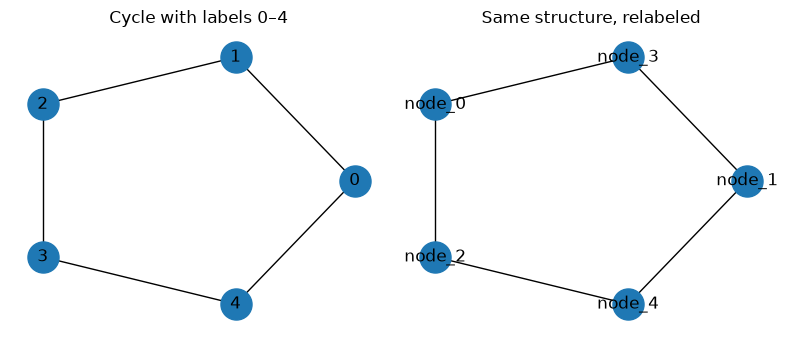

In [15]:
C1 = nx.cycle_graph(5)
rename = {i: f"node_{(2*i+1)%5}" for i in range(5)}
C2 = nx.relabel_nodes(C1, rename)
print("Isomorphic?", nx.is_isomorphic(C1, C2))
fig, axes = plt.subplots(1,2,figsize=(8,3.5))
nx.draw_networkx(C1, pos=nx.circular_layout(C1), ax=axes[0], node_size=500)
nx.draw_networkx(C2, pos=nx.circular_layout(C2), ax=axes[1], node_size=500)
axes[0].set_title("Cycle with labels 0–4")
axes[1].set_title("Same structure, relabeled")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 10. Feynman diagrams as graph-like structures

Feynman diagrams are useful physics examples of graph-like objects: vertices represent interactions and edges represent propagators. They are richer than ordinary unlabeled graphs because particle types, line types, orientations, momenta, and physical rules may carry additional information. The sketch below is an illustrative three-leg interaction, not a complete specification of a scattering process.

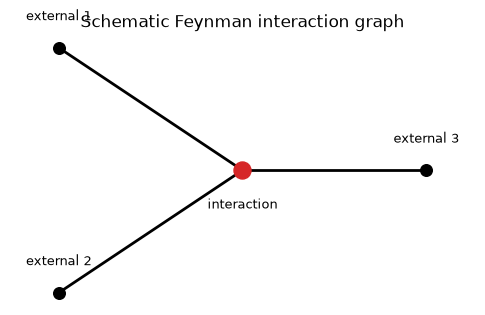

In [16]:
# Schematic three-leg interaction graph.
pos = {"external 1":(-1.2,.8), "external 2":(-1.2,-.8),
       "external 3":(1.2,0), "interaction":(0,0)}
edges = [("external 1","interaction"),("external 2","interaction"),
         ("interaction","external 3")]
plt.figure(figsize=(6,3.5))
for u,v in edges:
    x0,y0 = pos[u]; x1,y1 = pos[v]
    plt.plot([x0,x1],[y0,y1],color="black",linewidth=2)
for n,(x,y) in pos.items():
    plt.scatter([x],[y],s=150 if n=="interaction" else 70,
                color="tab:red" if n=="interaction" else "black",zorder=3)
    plt.text(x,y-.25 if n=="interaction" else y+.18,n,ha="center",fontsize=9)
plt.title("Schematic Feynman interaction graph")
plt.axis("equal"); plt.axis("off"); plt.show()

## 11. Computation graphs are DAGs

A computation graph records dependencies among inputs, operations, and intermediate values. Consider

$$z=(x+y) \, \sigma(x), \qquad  \sigma(x)= \frac{1}{1+e^{-x}}.$$

The inputs \(x,y\) feed into addition; \(x\) also feeds into the sigmoid; the two results feed into multiplication. This is a DAG, and automatic differentiation applies the chain rule along its dependencies.

**Distinction:** the input graph for a GNN describes relationships in the data. A computation graph describes the operations used to calculate a model's output.

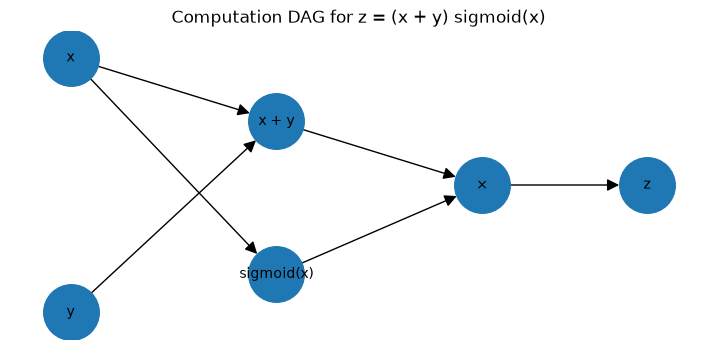

Is DAG? True
Topological order: ['x', 'y', 'sigmoid', 'add', 'multiply', 'z']


In [17]:
comp = nx.DiGraph([
    ("x","add"),("y","add"),("x","sigmoid"),
    ("add","multiply"),("sigmoid","multiply"),("multiply","z")
])
pos = {"x":(0,1),"y":(0,-1),"add":(1.5,.5),
       "sigmoid":(1.5,-.7),"multiply":(3,0),"z":(4.2,0)}
labels = {"x":"x","y":"y","add":"x + y","sigmoid":"sigmoid(x)",
          "multiply":"×","z":"z"}
plt.figure(figsize=(9,4))
nx.draw_networkx(comp,pos=pos,labels=labels,with_labels=True,
                 node_size=1600,font_size=10,arrows=True,arrowsize=18)
plt.title("Computation DAG for z = (x + y) sigmoid(x)")
plt.axis("off"); plt.show()
print("Is DAG?", nx.is_directed_acyclic_graph(comp))
print("Topological order:", list(nx.topological_sort(comp)))

In [18]:
import torch
x = torch.tensor(0.7, requires_grad=True)
y = torch.tensor(1.2, requires_grad=True)
z = (x + y) * torch.sigmoid(x)
z.backward()
print("z =", z.item())
print("dz/dx =", x.grad.item())
print("dz/dy =", y.grad.item())

z = 1.2695567607879639
dz/dx = 1.089442253112793
dz/dy = 0.6681877374649048


## Dense Neural Networks as Complete Bipartite Graphs

A **dense neural network** (also called a fully connected neural network) can be represented using graph theory. Each neuron is a vertex, and each connection between neurons in consecutive layers is an edge.

Consider two consecutive layers:
- An input layer containing \(m\) neurons.
- A hidden layer containing \(n\) neurons.

In a dense layer, every neuron in the input layer is connected to every neuron in the hidden layer. The resulting graph between these two layers is the **complete bipartite graph** $K_{m,n}$.

Recall that a bipartite graph has a vertex set that can be partitioned into two disjoint sets, with every edge joining vertices from different sets. In $K_{m,n}$, every possible edge between the two sets is present.

If the two layers have vertex sets

$$
U=\{u_1,\ldots,u_m\},
\qquad
V=\{v_1,\ldots,v_n\},
$$

then the edge set is

$$
E=\{(u_i,v_j):1\leq i\leq m,\ 1\leq j\leq n\}.
$$

Consequently, the number of edges is

$$
|E|=mn.
$$

For example, a layer with three neurons connected to a layer with four neurons gives the graph $K_{3,4}$, containing $3+4=7$ vertices and $3\cdot4=12$ edges.

### From two layers to a neural network

A network with multiple layers can be represented as a sequence of complete bipartite graphs. If the layer widths are $n_0,n_1,\ldots,n_L$, then the connections between layers $\ell-1$ and $\ell$ form a complete bipartite graph

$$
K_{n_{\ell-1},n_\ell}.
$$

The entire network is a **layered directed graph**: edges point from earlier layers to later layers, and there are no direct connections between nonconsecutive layers in the standard fully connected architecture.

Each edge carries a learnable weight $w_{ij}^{(\ell)}$, and each neuron in a non-input layer typically applies a bias and an activation function. Thus, the graph specifies the connectivity, while the weights, biases, and activation functions specify the computation.

For a fully connected layer, the computation is

$$
\mathbf{h}^{(\ell)}
=
\sigma\left(
W^{(\ell)}\mathbf{h}^{(\ell-1)}
+\mathbf{b}^{(\ell)}
\right),
$$

where $W^{(\ell)}$ has shape $n_\ell\times n_{\ell-1}$. Every entry of this weight matrix corresponds to a connection between a neuron in the previous layer and a neuron in the current layer.

**Important distinction:** The complete bipartite graph describes the *connectivity pattern*. It does not mean that all edge weights are equal, nor does it imply that the neural network computes a linear function. Learnable weights, biases, and nonlinear activations determine the actual computation.

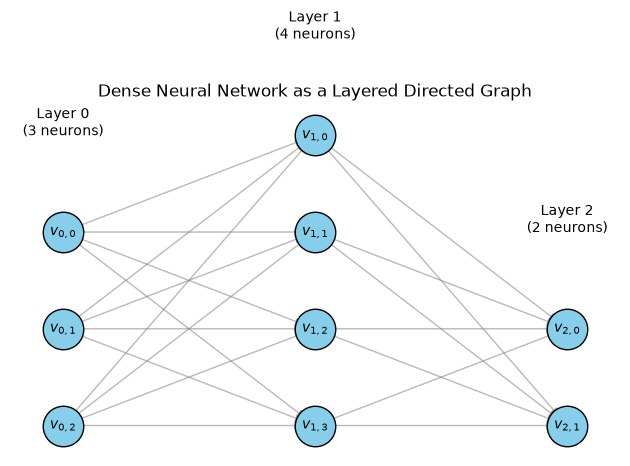

Number of neurons: 9
Number of connections: 20


In [19]:
import networkx as nx
import matplotlib.pyplot as plt


def draw_dense_network(layer_sizes):
    """
    Visualize a dense neural network as a layered directed graph.

    Each consecutive pair of layers is fully connected.
    """
    G = nx.DiGraph()
    pos = {}
    layer_nodes = []

    # Create vertices and assign positions layer by layer.
    for layer_idx, size in enumerate(layer_sizes):
        nodes = [(layer_idx, neuron_idx) for neuron_idx in range(size)]
        layer_nodes.append(nodes)

        for neuron_idx, node in enumerate(nodes):
            G.add_node(node)
            pos[node] = (layer_idx, size - 1 - neuron_idx)

    # Connect every neuron to every neuron in the next layer.
    for layer_idx in range(len(layer_sizes) - 1):
        for source in layer_nodes[layer_idx]:
            for target in layer_nodes[layer_idx + 1]:
                G.add_edge(source, target)

    # Draw edges first so that nodes appear on top.
    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=12,
        edge_color="gray",
        alpha=0.55,
        connectionstyle="arc3,rad=0.0",
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=850,
        node_color="skyblue",
        edgecolors="black",
    )

    # Label neurons and layers.
    labels = {
        node: f"$v_{{{node[0]},{node[1]}}}$"
        for node in G.nodes()
    }
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

    for layer_idx, nodes in enumerate(layer_nodes):
        y_center = (len(nodes) - 1) / 2
        plt.text(
            layer_idx,
            y_center + len(nodes) / 2 + 0.5,
            f"Layer {layer_idx}\n({layer_sizes[layer_idx]} neurons)",
            ha="center",
            fontsize=10,
        )

    plt.title(
        "Dense Neural Network as a Layered Directed Graph"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Number of neurons: {G.number_of_nodes()}")
    print(f"Number of connections: {G.number_of_edges()}")


draw_dense_network([3, 4, 2])

## 12. Why these ideas matter before GNNs

- **Vertices and edges** define the domain.
- **Neighborhoods** encode local connectivity.
- **Adjacency matrices** give an algebraic representation.
- **Degree and shortest paths** describe local and global structure.
- **Geometric graphs** combine connectivity with coordinates.
- **Permutations** formalize the arbitrary choice of vertex labels.
- **Homomorphisms and isomorphisms** describe structure-preserving maps.
- **Permutation-invariant aggregation** previews graph-level readout.
- **Computation DAGs** describe the dependency structure of the model itself.

Hamilton's *Graph Representation Learning* is a useful supplement because it connects graph-theoretic data structures to representation-learning problems. The next notebook will build on these foundations to study GNNs mathematically.

## 13. Examples and non-examples

1. **Directed vs. undirected:** \(u\to v\) does not imply \(v\to u\).
2. **Connectivity vs. geometry:** an edge does not automatically specify Euclidean distance.
3. **Degree vs. global importance:** degree counts direct neighbors but does not fully measure global influence.
4. **Homomorphism vs. isomorphism:** homomorphisms may collapse vertices; isomorphisms are bijective.
5. **Graph vs. simplicial complex:** a graph records edges; a simplicial complex can record filled triangles and higher-dimensional simplices.
6. **Input graph vs. computation graph:** data relationships and computational dependencies are different structures.

## 14. Exercises

1. Construct a five-vertex graph with an isolated vertex; compute its adjacency matrix, degree matrix, and degrees.
2. Construct a directed graph whose adjacency matrix is not symmetric. Compute in-degrees and out-degrees.
3. Use the weighted four-node example to compute all shortest paths and the diameter.
4. Draw a path, cycle, complete graph, bipartite graph, and tree. Check edge counts and degrees.
5. Generate points in $\mathbb R^2$, build a radius graph and a $k$-NN graph, and compare connectivity.
6. Construct a graph with homophily $h=1$, then change one edge to lower the ratio.
7. Verify that $A'=PAP^\top$ preserves adjacency eigenvalues under a permutation.
8. Construct $C_6\to K_3$ as a homomorphism and explain why it is not an isomorphism.
9. Extend the Feynman sketch with a second interaction vertex joined by an internal propagator.
10. Draw a computation DAG for $f(x,y)=\log(1+\exp(xy))$ and give a topological ordering.

## Summary

We covered graph definitions, neighborhoods, subgraphs, adjacency and degree matrices, connectivity, shortest paths, diameter, graph families, geometric graphs, homophily, meshes and simplicial complexes, permutations, homomorphisms/isomorphisms, Feynman diagrams, and computation DAGs.

**Next notebook:** Graph Neural Networks. We can now focus on how node features are transformed and information is propagated over a graph.

## References

- Borde, H. S. de Ocáriz, & Bronstein, M. *Mathematical Foundations of Geometric Deep Learning*, §7.1–§7.2, pp. 65–73, arXiv:2508.02723 (2025).
- Hamilton, W. L. *Graph Representation Learning*. Morgan & Claypool, 2020. [Author's book page and chapter drafts](https://www.cs.mcgill.ca/~wlh/grl_book/). Chapter 2, *Background and Traditional Approaches*, is the main supplement for this notebook.
- [NetworkX documentation](https://networkx.org/documentation/stable/).

The code examples are small experiments intended to illuminate the manuscript's definitions, not replace them.